## 13.3 적대적 생성 신경망(GAN)이란
생성 모델은 쵀대한 진짜와 비슷한 데이터를 생성하려는 생성자와 가짜를 구별하려는 판별자가 각각 존재하여 서로 적대적으로 학습한다. 적대적 학습에서는 판별자를 먼저 학습시킨 후 생성자를 학습시키는 과정을 반복한다. 판별자 학습은 크게 두 단계로 진행된다. 먼저 실제 이미지를 입력해서 네트워크(신경망)가 해당 이미지를 진짜로 분류하도록 학습시킨다. 그런 다음 생성자가 생성한 모조 이미지를 입력해서 해당 이미지를 가짜로 분류하도록 학습시킨다. 이 과정을 거쳐 판별자는 실제 이미지를 진짜로 분류하고, 모조 이미지를 가짜로 분류한다. 이와 같은 학습과정을 반복하면 판별자와 생성자가 서로를 적대적인 경쟁자로 인식하여 모두 발전하게 된다. 결과적으로 생성자는 진짜 이미지에 완벽히 가까울 정도의 유사한 모조 이미지를 만들고, 이에 따라 판별자는 실제 이미지와 모조 이미지를 구분할 수 없게 된다. 즉, 생성자는 분류에 성공할 확률을 낮추고 판별자는 분류에 성공할 확률을 높이면서 서로 경쟁적으로 발전시키는 구조이다.

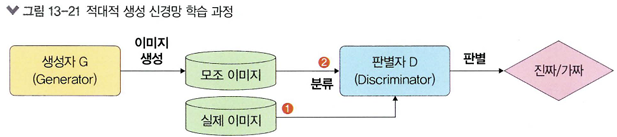

### 13.3.1 GAN 동작 원리
적대적 생성 신경망은 생성자와 판별자 네트워크 두 개로 구성되어 있다. 이름에서 알 수 있듯이 두 네트워크는 서로 적대적으로 경쟁하여 학습을 진행한다. 생성자 G는 판별자 D를 속이려고 원래 이미지와 최대한 비슷한 이미지를 만들도록 학습한다. 반대로 판별자 D는 원래 이미지와 생성자 G가 만든 이미지를 잘 구분하도록 학습을 진행한다.
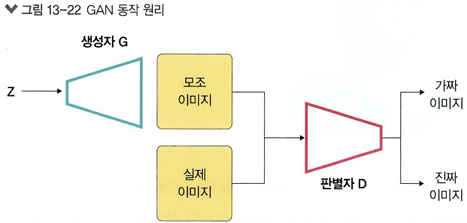

먼저 판별자 D부터 살펴본다. 판별자 D의 역할은 주어진 입력 이미지가 진짜 이미지인지 가짜 이미지인지 구별하는 것이다. 즉, 이미지 x가 입력으로 주어졌을 때 판별자 D의 출력에 해당하는 D(x)가 진짜 이미지일 확률을 반환한다. 반면 생성자 G의 역할은 판별자 D가 진짜인지 가짜인지 구별할 수 없을 만큼 진짜와 같은 모조 이미지를 노이즈 데이터를 사용하여 만들어내는 것이다. 예를 들어 실제 이미지인 알파벡 z가 입력으로 주어졌을 때 판별자 z를 학습한다. 또한, 생성자는 임의의 노이즈 데이터를 사용하여 모조 이미지 z'(G(z))를 생성한다. 이러한 G(z)를 다시 판별자 D의 입력으로 주면 판별자는 G(z)가 실제 이미지일 확률을 반환한다.

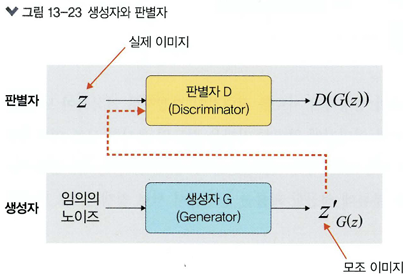

실제 데이터를 판단하려고 판별자 D를 학습시킬 때는 생성자 G를 고정시킨 채 실제 이미지는 높은 확률을 반환하는 방향으로, 모조 이미지는 낮은 확률을 반환하는 방향으로 가중치를 업데이트한다. GAN의 손실함수는 다음과 같다.

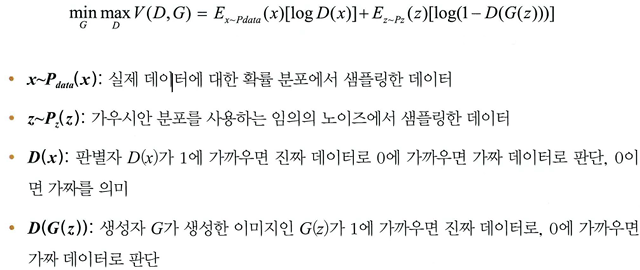

수식에서 판별자 D는 실제 이미지 x를 입력받을 경우 D(x)를 1로 예측하고, 생성자가 잠재 벡터에서 생성한 모조 이미지 G(z)를 입력받을 경우 D(G(z))를 0으로 예측한다. 따라서 판별자가 모조 이미지 G(z)를 입력받을 경우 1로 예측하도록 하는 것이 목표이다. 다시 앞의 손실 함수 전체로 돌아오면, 눈으로 보는 것처럼 상당히 복잡해보인다. 따라서 판별자 D와 생성자 G부분으로 나누어 살펴본다. 판별자 D는 다음 식의 최댓값으로 파라미터를 업데이트하는 것을 목표로 한다. 참고로 판별자는 앞의 수식에서 좌항과 우항을 모두 사용한다.

image.png

이때 판별자 입장에서는 D(x)=1, D(G(z))=0이 최상의 결과(진짜 이미지는 1, 가짜 이미지는 0을 출력할 경우)가 될 것이기 때문에 이 식의 최댓값으로 업데이트해야 한다. 또한, 판별자 입장에서는 log(D(x))와 log(1-D(G(z))) 모두 최대가 되어야 한다. 즉, D(x)는 1이 되어야 실제 이미지를 진짜라고 분류하며, 1-D(G(z))는 1이 되어야 생성자가 만든 모조 이미지를 가짜라고 분류한다. 반면에 생성자 G는 다음 식의 최솟값으로 파라미터를 업데이트하는 것을 목표로 한다.

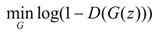

이때 생성자 입장에서는 D(G(z))=1이 최상의 결과(판별자가 가짜 이미지를 1로 출력한 경우)가 될 것이기 때문에 이 식의 최솟값으로 업데이트해야 한다. 참고로 GAN을 학습시키려면 판별자와 생성자의 파라미터를 번갈아 가며 업데이트해야 한다. 또한, 판별자의 파라미터를 업데이트할 때는 생성자의 파라미터를 조정시키고, 생성자의 파라미터를 업데이트할 때는 판별자의 파라미터를 고정해야 한다.

### 13.3.2 GAN 구현
GAN 예제 역시 MNIST 데이터셋을 사용하여 파이토치로 구현하는 방법을 알아본다. 먼저 필요한 라이브러리를 호출한다.

In [1]:
import imageio # 이미지 데이터를 읽고 쓸 수 있는 쉬운 인터페이스를 제공하는 라이브러리
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib
import matplotlib.pylab as plt

from torchvision.utils import make_grid, save_image
import torchvision.datasets as datasets
import torchvision.transforms as transforms
matplotlib.style.use('ggplot') # 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

1. 맷플롯립 라이브러리는 시각화에 사용한다. 맷플롯립은 폰트, 색상 등을 변경하여 사용할 수 있는데 예제에서는 스타일시트를 바꾸어서 사용했다. 스타일시트로 사용할 수 있는 것들은 다음 코드와 같이 확인할 수 있다.

import matplotlib.pyplot as plt

plt.style.available

다음은 사용 가능한 스타일시트 목록에 대한 출력 결과이다.

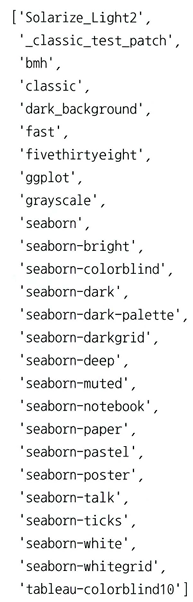

'ggplot' 스타일시트는 다음 그림과 같이 격자무늬의 백그라운드를 삽입하고자 할 때 사용한다.

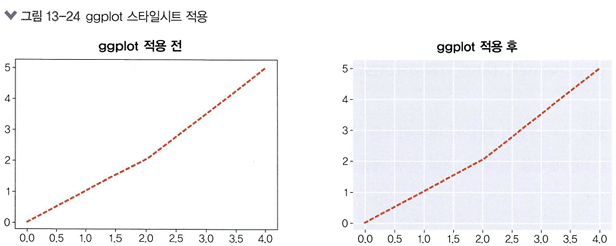

학습을 위해 사용 가능한 스타일시트를 하나씩 적용해 보는 것도 도움이 된다. 필요한 변수에 대한 값을 지정한다.

In [2]:
batch_size = 512
epochs = 200
sample_size = 64 # 1
nz = 128 # 2
k = 1 # 3

1. 노이즈 벡터를 사용하여 가짜 이미지를 생성한다. sample_size는 생성자에 제공할 고정 크기의 노이즈 벡터에 대한 크기이다.
2. 잠재 벡터의 크기를 의미한다. 이때 잠재 벡터의 크기는 입력 크기와 동일해야 한다.
3. 판별자에 적용할 스텝 수를 의미한다. 스텝 수를 1로 지정한 이유는 훈련 비용을 최소화하기 위함이다.

예제에서 진행할 MNIST를 내려받아 정규화를 적용한다. 이후에는 데이터로더에 데이터를 전달하여 모델의 학습에 사용할 수 있도록 한다.

In [3]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2278 (delta 3), reused 2 (delta 2), pack-reused 2262 (from 2)
Receiving objects: 100% (2278/2278), 330.29 MiB | 34.37 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(), # 이미지를 텐서로 변환
    transforms.Normalize((0.5,),(0.5,)), # 이미지를 평균이 0.5, 표준편차가 0.5가 되도록 정규화
])

train_dataset = datasets.MNIST(root = '080289/chap13/data', train = True, transform = transform, download = True)
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


데이터셋이 준비되었기 때문에 네트워크를 생성할 텐데, 먼저 생성자 네트워크를 만들어 본다. 간단한 예제를 위해 네 개의 선형 계층과 세 개의 리키렐루 활성화 함수를 사용한다.

In [5]:
class Generator(nn.Module):
  def __init__(self, nz):
    super(Generator, self).__init__()
    self.nz = nz
    self.main = nn.Sequential(
        nn.Linear(self.nz, 256), nn.LeakyReLU(0.2),
        nn.Linear(256, 512), nn.LeakyReLU(0.2),
        nn.Linear(512, 1024), nn.LeakyReLU(0.2),
        nn.Linear(1024, 784), nn.Tanh(),
    )

  def forward(self, x):
    return self.main(x).view(-1, 1, 28, 28) # 생성자 네트워크의 반환값은 '배치 크기x1x28x28'이 됩니다.

생성자 네트워크가 완료되었고, 이제 판별자 네트워크를 생성해본다. 판별자는 이진 분류자라는 것을 고려하여 신경망을 구축해야 한다.

In [6]:
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()
    self.n_input = 784 # 판별자의 입력 크기
    self.main = nn.Sequential(
        nn.Linear(self.n_input, 1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(1024, 512),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(256, 1),
        nn.Sigmoid(),
    )
  def forward(self, x):
    x = x.view(-1, 784)
    return self.main(x) # 이미지가 진짜인지 가짜인지를 분류하는 값을 반환

앞에서 생성한 생성자와 판별자 네트워크를 초기화한다. 이때 생성자는 잠재 벡터 nz라는 변수를 파라미터로 전달해야 한다.

In [7]:
generator = Generator(nz).to(device)
discriminator = Discriminator().to(device)
print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


이제 모델의 네트워크에서 사용할 옵티마이저와 손실 함수를 정의한다. 중요한 것은 생성자와 판별자에서 사용할 옵티마이저를 따로 정의해야 한다는 것이다.

In [8]:
optim_g = optim.Adam(generator.parameters(), lr = 0.0002)
optim_d = optim.Adam(discriminator.parameters(), lr=0.0002)

criterion = nn.BCELoss()

losses_g = [] # 매 에포크마다 발생하는 생성자 오차를 저장하기 위한 리스트형 변수
losses_d = [] # 매 에포크마다 발생하는 판별자 오차를 저장하기 위한 리스트형 변수
images = [] # 생성자에 의해 생성되는 이미지를 저장하기 위한 리스트형 변수

생성자에 의해 만들어지는 새로운 이미지(텐서)를 저장하기 위한 함수를 저장한다. 이 함수는 모델 학습에 반드시 필요한 것은 아니지만 이미지가 생성되는 과정을 이해할 수 있도록 시각화하여 보여준다.

In [9]:
def save_generator_image(image, path):
  save_image(image, path)

판별자를 학습시키기 위한 함수를 정의한다. 판별자의 학습은 진짜 데이터의 레이블과 가짜 데이터의 레이블을 모두 이용하여 학습한다.

In [10]:
def train_discriminator(optimizer, data_real, data_fake):
  b_size = data_real.size(0) # 배치 크기 정보 얻기
  real_label = torch.ones(b_size, 1).to(device) # 1
  fake_label = torch.zeros(b_size, 1).to(device) # 2
  optimizer.zero_grad()
  output_real = discriminator(data_real)
  loss_real = criterion(output_real, real_label) # 진짜 데이터를 판별자에 제공하여 학습한 결과와 진짜 데이터의 레이블을 이용하여 오차를 계산
  output_fake = discriminator(data_fake)
  loss_fake = criterion(output_fake, fake_label) # 가짜 데이터를 판별자에 제공하여 학습한 결과와 가짜 데이터의 레이블을 이용하여 오차를 계산
  loss_real.backward()
  loss_fake.backward()
  optimizer.step()
  return loss_real + loss_fake # 진짜 데이터와 가짜 데이터의 오차가 합쳐진 최종 오차를 반환

1. GAN에서는 모델 훈련을 위해 진짜 이미지와 생성자에서 생성한 가짜 이미지가 필요하다. 그뿐만 아니라 레이블 정보도 필요한데, 레이블 정보는 텐서 형태를 가져야 하며 배치 크기와도 동일해야 한다. 먼저 진짜 데이터에 대한 레이블을 생성한다.

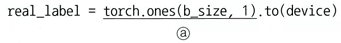

- a. 1 값을 가진 (b_size x 1) 크기의 텐서를 생성
2. 가짜 데이터에 대한 레이블을 생성한다.
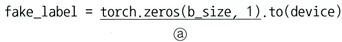

- a. 0 값을 가진 (b_size x 1) 크기의 텐서를 생성

이제 생성자 학습을 위한 함수를 정의할 텐데, 상대적으로 판별자의 네트워크보다는 간단하다.


In [12]:
def train_generator(optimizer, data_fake):
  b_size = data_fake.size(0)
  real_label = torch.ones(b_size, 1).to(device) #1
  optimizer.zero_grad()
  output = discriminator(data_fake)
  loss = criterion(output, real_label)
  loss.backward()
  optimizer.step()
  return loss

1. 생성자 네트워크에서는 가짜 데이터만 사용하고 있는데, 생성자 입장에서는 가짜 데이터가 실제로 진짜라는 것에 주의할 필요가 있다.

이제 for 구문을 이용하여 200회 에포크만큼 모델을 학습시킨다.

In [13]:
batch_size = 64
epochs = 20

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
generator.train() # 생성자를 학습 모드로 설정
discriminator.train() # 판별자를 학습 모드로 설정

for epoch in range(epochs):
  loss_g = 0.0 # 생성자 오차를 추적(저장)하기 위한 변수
  loss_d = 0.0 # 판별자 오차를 추적(저장)하기 위한 변수
  for idx, data in tqdm(enumerate(train_loader), total=int(len(train_dataset)/train_loader.batch_size)):
    image, _ = data # 학습을 위한 이미지 데이터를 가져옵니다.
    image = image.to(device) # 데이터셋이 CPU/GPU 장치를 사용하도록 지정
    b_size = len(image)
    for step in range(k): # k(1) 스텝 수에 따라 판별자를 실행, 이떄 k 수를 증가시킬 수 있지만 학습 시간이 길어질 수 있으므로 주의
      data_fake = generator(torch.randn(b_size, nz).to(device)).detach() # 1
      data_real = image
      loss_d += train_discriminator(optim_d, data_real, data_fake) # 1'
    data_fake = generator(torch.randn(b_size, nz).to(device))
    loss_g += train_generator(optim_g, data_fake) # 생성자 학습
  generated_img = generator(torch.randn(b_size, nz).to(device)).cpu().detach() # 생성자를 이용하여 새로운 이미지를 생성하고 CPU 장치를 이용하여 디스크에 저장
  generated_img = make_grid(generated_img)
  save_generator_image(generated_img, f"/content/drive/MyDrive/GAN{epoch}.png") # 생성된 이미지(텐서)를 디스크에 저장
  epoch_loss_g = loss_g / idx # 에포크에 대한 총 생성자 오차 계산
  epoch_loss_d = loss_d / len(train_loader) # 에포크에 대한 총 판별자 오차 계
  losses_g.append(epoch_loss_g)
  losses_d.append(epoch_loss_d)

  print(f"Epoch {epoch} of {epochs}")
  print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")

118it [00:12,  9.31it/s]                         


Epoch 0 of 20
Generator loss: 2.31586838, Discriminator loss: 1.23732626


118it [00:14,  8.02it/s]                         

Epoch 1 of 20
Generator loss: 5.17675972, Discriminator loss: 0.55086863



118it [00:14,  7.88it/s]


Epoch 2 of 20
Generator loss: 1.87696445, Discriminator loss: 1.34715796


118it [00:15,  7.43it/s]                         

Epoch 3 of 20
Generator loss: 3.61792874, Discriminator loss: 0.65683734



118it [00:13,  8.92it/s]                         

Epoch 4 of 20
Generator loss: 1.42512882, Discriminator loss: 1.36774194



118it [00:11, 10.32it/s]                         

Epoch 5 of 20
Generator loss: 2.76028299, Discriminator loss: 0.93148136



118it [00:11, 10.46it/s]                         

Epoch 6 of 20
Generator loss: 1.65779448, Discriminator loss: 1.09617352



118it [00:13,  8.76it/s]

Epoch 7 of 20
Generator loss: 1.36016297, Discriminator loss: 1.24660146



118it [00:15,  7.66it/s]                         


Epoch 8 of 20
Generator loss: 0.95531392, Discriminator loss: 1.06695461


118it [00:15,  7.75it/s]                         

Epoch 9 of 20
Generator loss: 1.90560460, Discriminator loss: 0.73693293



118it [00:12,  9.12it/s]                         

Epoch 10 of 20
Generator loss: 3.43853378, Discriminator loss: 0.65690035



118it [00:12,  9.31it/s]                         


Epoch 11 of 20
Generator loss: 3.98717833, Discriminator loss: 0.52918822


118it [00:12,  9.35it/s]                         

Epoch 12 of 20
Generator loss: 3.14225149, Discriminator loss: 0.53291166



118it [00:12,  9.22it/s]                         


Epoch 13 of 20
Generator loss: 3.65816808, Discriminator loss: 0.44337064


118it [00:12,  9.24it/s]                         

Epoch 14 of 20
Generator loss: 3.73896480, Discriminator loss: 0.50264901



118it [00:12,  9.69it/s]                         

Epoch 15 of 20
Generator loss: 4.34568834, Discriminator loss: 0.26056647



118it [00:12,  9.32it/s]                         

Epoch 16 of 20
Generator loss: 3.45366645, Discriminator loss: 0.50882649



118it [00:13,  8.52it/s]                         

Epoch 17 of 20
Generator loss: 2.80764270, Discriminator loss: 0.50896132



118it [00:16,  6.96it/s]                         

Epoch 18 of 20
Generator loss: 3.17324495, Discriminator loss: 0.42148751



118it [00:16,  7.18it/s]                         


Epoch 19 of 20
Generator loss: 2.88053727, Discriminator loss: 0.58365488


1. 생성자에서 새로운 이미지 데이터(텐서)를 생성하기 위해서는 노이즈 데이터가 필요하다. 노이즈 데이터는 torch.randn()을 이용해서 생성할 수 있으며, 여기에서 사용되는 파라미터는 다음과 같다.

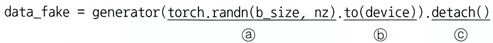

- a. 생성자에서 가짜 이미지를 생성하기 위해서는 생성자에 노이즈 데이터(벡터)를 제공해야 한다. 노이즈 데이터는 잠재 벡터(nz)의 크기와 동일해야 하며, 평균이 0이고 표준편차가 1인 가우시안 정규분포를 이용하여 (b_size x nz) 크기를 갖도록 한다.
- b. 모델이 데이터를 처리하려면 모델과 데이터 모두 동일한 장치(CPU 혹은 GPU)를 사용해야 한다. 여기에서는 to(divice)를 이용하여 모델이 사용할 장치를 지정한다.
- c. detach()는 Crtl+X와 같은 기능을 한다. 즉, detach()를 통해 떼어 낸 데이터를 이용하여 1'처럼 판별자를 학습시키고 그 결과를 loss_d에 붙여 넣는다.

0 ` 1번째 에포크에서 생성된 이미지는 노이즈 그 이상의 의미를 갖지 않는다. 하지만 100번쨰 에포크에서는 이미지의 형태가 보이지만 여전히 이미지 주위에 노이즈가 많은 것을 볼 수 있다. 그리고 마지막 199번째 에포크에서는 노이즈가 많이 없어지면서 좀 더 선명한 이미지를 보여준다. 이번에는 생성자와 판별자의 오차에 대한 변화를 그래프로 살펴본다.

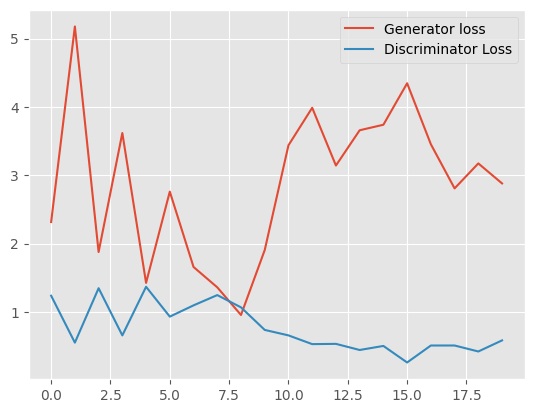

In [18]:
plt.figure()
losses_g = [fl.item() for fl in losses_g]
plt.plot(losses_g, label='Generator loss')
losses_d = [f2.item() for f2 in losses_d]
plt.plot(losses_d, label='Discriminator Loss')
plt.legend()

처음 몇 에포크 동안 생성자의 오차는 증가하고 판별자의 오차는 감소하는 것을 볼 수 있다. 이러한 증상이 나타나는 이유는 학습 초기 단계에 생성자는 좋은 가짜 이미지를 생성하지 못하기에 판별자가 실제 이미지와 가짜 이미지를 쉽게 구분할 수 있기 때문이다. 하지만 학습이 진행됨에 따라 생성자는 진짜 와 같은 가짜 이미지를 만들며 판별자는 가짜 이미지 중 일부를 진짜로 분류한다. 따라서 그림과 같이 생성자의 오차가 감소하면 판별자의 오차는 증가한다. 앞의 이미지를 하나씩 쪼개서 확인하고 싶다면 다음 코드와 같이 실행하면 된다. 생성된 열 개의 이미지를 보여준다.

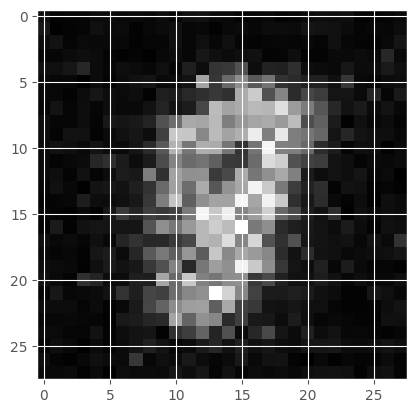

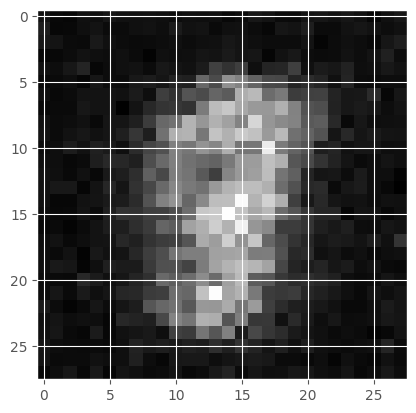

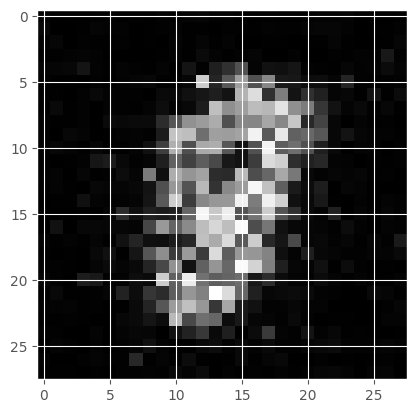

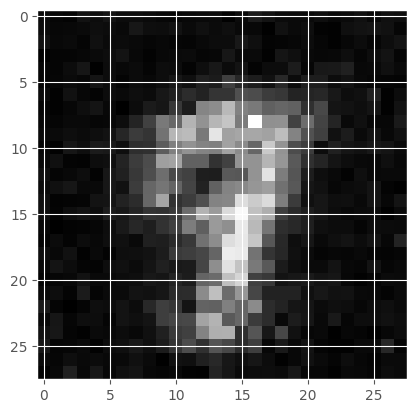

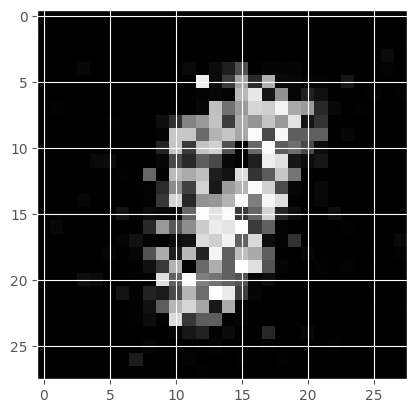

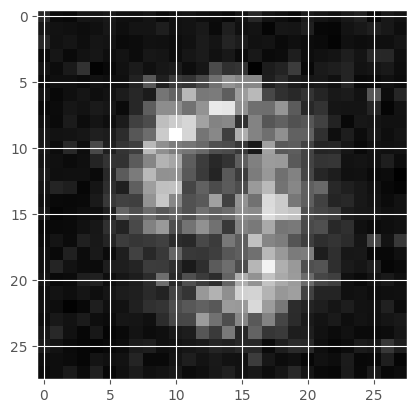

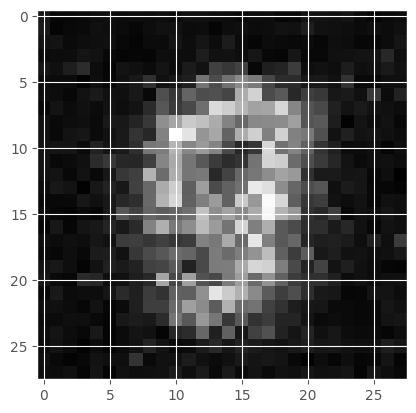

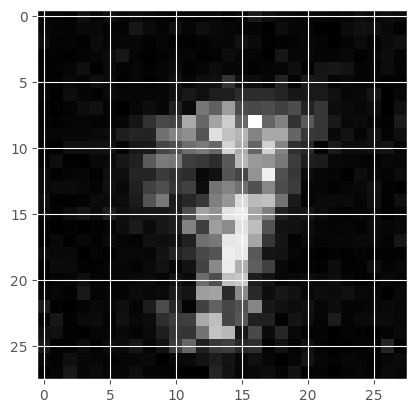

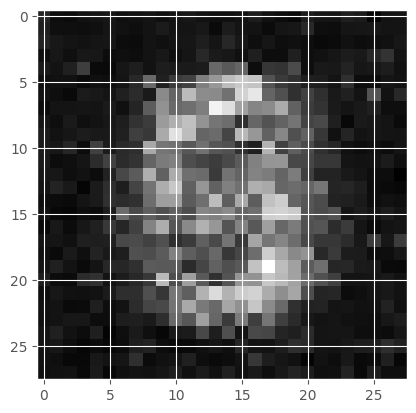

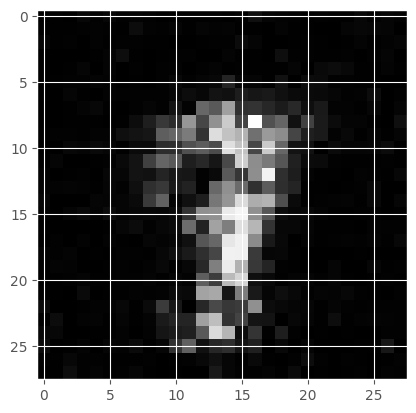

In [20]:
import numpy as np

fake_images = generator(torch.randn(b_size, nz).to(device))
for i in range(10):
  fake_images_img = np.reshape(fake_images.data.cpu().numpy()[i], (28, 28))
  plt.imshow(fake_images_img, cmap='gray')
  plt.savefig('/content/drive/MyDrive/GAN/fake_images_img' + str(i) + '.png')
  plt.show()

에포크를 사용하여 학습 횟수를 늘리면 더 선명한 결과를 얻을 수 있다.

## 13.4 GAN 파생 기술
GAN은 생성자와 판별자가 서로 대결하면서 학습하는 구조이기 때문에 학습이 매우 불안정하다. 생성자와 판별자 중 한쪽으로 치우친 훈련이 발생하면 성능에 문제가 생겨 정상적인 분류(진짜 혹은 가짜 분류)가 불가능하다. 이러한 제약을 해결한 모델이 DCGAN이다. 이름에서도 알 수 있듯이 DCGAN은 GAN 학습에 CNN을 사용하는 것이다. GAN과 DCGAN이 가짜 이미지 생성을 위해 임의의 노이즈 값을 사용했다면 cGAN은 출력에 어떤 조건을 주어 변형하는 모델이다. 즉, GAN이 임의의 노이즈로 무작위 이미지를 출력한다면, cGAN은 시드 역할을 하는 임의의 노이즈와 함께 어떤 조건이 추가된다. 조건이 추가되고 데이터 훈련 과정에서 인간이 통제할 수 있게 되면서 실제 이미지와 가깝거나 원래 이미지에 없던 문자열 태그 등도 넣는 것이 가능해졌다. 또한 CycleGAN이라는 것도 있다. CycleGAN은 사진이 주어졌을 때 다른 사진으로 변형시키는 모델이다. 예를 들어 말을 얼룩말로 변환하는 것이 가능하다. 참고로 CycleGAN은 POX2PIX라는 원리를 이용한다.

### 13.4.1 DCGAN
DCGAN은 GAN과 동일하게 입력된 이미지를 바탕으로 그것과 매우 유사한 가짜 이미지를 만들고, 이를 평가하는 과정을 반복하여 실제와 매우 유사한 이미지를 생산하는 학습법이다. 따라서 DCGAN 역시 생성자와 판별자 네트워크 두 개가 서로 적대적으로 학습하는 구조이다.

#### 생성자 네트워크
생성자는 임의의 입력을 받아들여 판별자에서 사용할 수 있는 이미지 데이터를 생성하며, 출력은 64X64가 된다. 임의의 입력으로 주어지는 노이즈 데이터는 '가로X세로' 형태가 아니기 때문에 입력 형태를 '가로X세로'로 변경해야 한다. 형태가 변경된 입력은 합성곱층으로 넘겨진 후 이미지 출력을 위해 분수-스트라이드 합성곱을 사용하여 출력 값을 키운다.

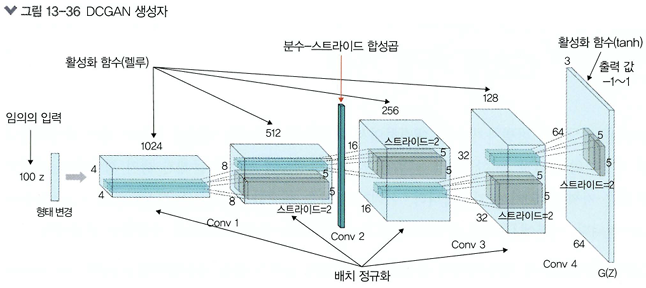

생성자 네트워크 특징은 다음과 같다.
- 풀링층을 모두 없애고, 분수-스트라이드 합성곱을 사용한다.
- 배치 정규화를 이용하여 네트워크의 층이 많아도 안정적으로 기울기를 계산할 수 있도록 한다. 단 배치 정규화를 모든 계층마다 추가할 경우 안정성이 떨어지는 문제가 있으므로 최종 출력층에서는 사용하지 않는다.
- 활성화 함수는 렐루를 사용하며, 최종 출력층에서는 하이퍼볼릭 탄젠트를 사용한다.

#### 판별자 네트워크
판별자 네트워크는 64X64 크기의 이미지를 입력받아 진짜 혹은 가짜의 1차원 결과를 출력한다. 활성화 함수로 리키렐루를 사용하며, 최종 출력층에서는 시그모이드 함수를 사용하여 0~1의 값을 출력한다.

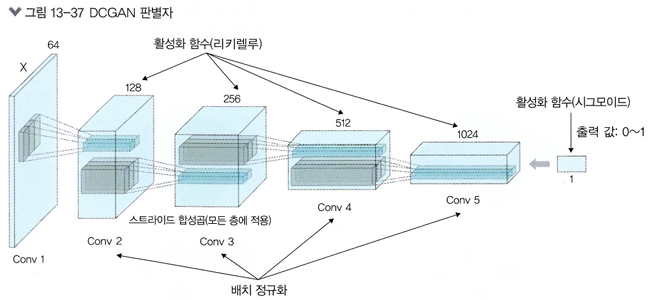

즉, 판별자 네트워크 특징은 다음과 같다.
- 풀링층을 모두 없애고, 스트라이드 합성곱을 사용한다.
- 배치 정규화를 이용하여 네트워크의 층이 많아도 안정적으로 기울기를 계산할 수 있도록 했다. 단 생성자 네트워크와 마찬가지로 배치 정규화를 모든 계층마자 추가하면 안정성이 떨어지는 문제가 있으므로 최초 입력층에서는 사용하지 않았다.
- 활성화 함수는 리키렐루를 사용하며, 최종 출력층에서는 시그모이드를 사용한다.


##### 스트라이드 합성곱과 분수-스트라이드 합성곱
판별자 네트워크에서 사용하는 스트라이드 합성곱은 합성곱에 단순히 스트라이드를 적용한 것이라고 생각하면 된다. 이때 스트라이드 값을 1 이상의 정수로 사용하면 풀링과 마찬가지로 출력 크기를 줄일 수 있다. 예를 들어 다음 그림과 같이 스트라이드 합성곱을 이용하여 2X2 크기의 특성 맵을 추출할 수 있다.
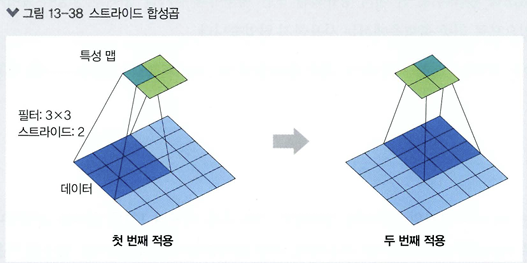

생성자 네트워크에서 사용하는 분수-스트라이드 합성곱은 스트라이드 값을 1보다 작은 분수를 사용하여 출력 크기를 키운다. 예를 들어 특성 크기 맵의 크기를 키우려면 2X2 크기의 특성 맵(다음 그림의 빨간색 박스 안의 파란색 부분)의 각 원소 사이와 바깥 부분에 모두 패딩(0)을 넣어 준 상태에서 3X3 필터로 합성곱을 수행하면 된다.

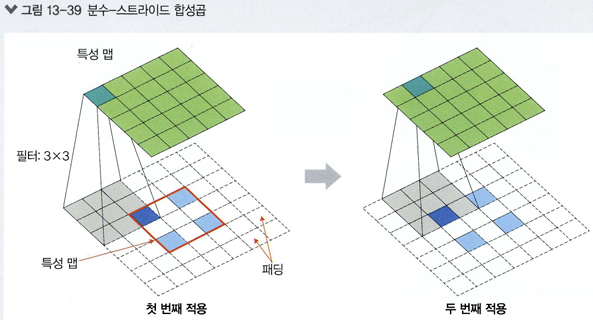

그럼 왜 생성자 네트워크에서는 분수-스트라이드 합성곱을 사용하고, 판별자 네트워크에서는 스트라이드 합성곱을 사용해야 할까요? 생성자 네트워크에서는 노이즈를 입력으로 받아 훈련 데이터셋의 이미지와 같은 해상도를 갖는 이미지를 생성해야 하기 때문에 공간을 확장시켜야 하는 분수-스트라이드 합성곱이 필요하다. 반면 판별자 네트워크는 실제 이미지와 생성자가 생성한 이미지 사이에서 어떤 이미지가 진짜인지 판별해야 하기 때문에 각 이미지의 특성을 추출할 수 있는 합성곱 연산을 수행한다. 그리고 이때 스트라이드 합성곱을 사용하면 특성을 잘 추출할 수 있다.

### 13.4.2 cGAN
cGAN은 GAN의 출력에 조건을 주어 통제하려는 시도에서 만들어졌다. 기존 GAN은 노이즈 벡터를 받아들여서 출력을 만들어 내는데, 이때 사람이 통제할 수 있는 부분이 없었다. 그렇다면 통제는 왜 필요할까? GAN을 이용하면 입력 이미지와 유사한 출력 이미지가 생성된다. 그런데 입력 이미지에 새로운 객체를 추가하거나 이미지에 자동으로 문자열 태그를 붙이고 싶다면 어떻게 해야 할까? 기존 GAN 기술을 이용할 때는 불가능했다. 하지만 cGAN을 이용하여 조건을 변경한다면 이 모든 것이 가능하다. 기본적으로 cGAN은 GAN 원리와 비슷하지만, 다음 그림과 같이 생성자와 판별자에 조건을 입력하는 부분에서 차이가 있다.

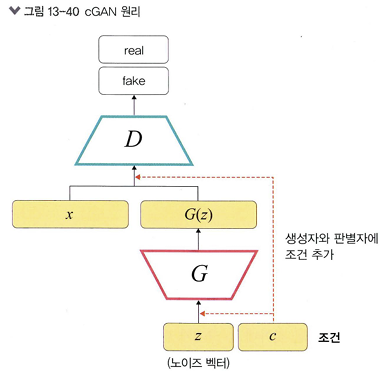

예를 들어 MNIST 데이터셋을 사용하여 데이터를 훈련시킨 후 숫자 1을 출력한다고 한다. 이때 생성자에 노이즈 벡터와 더불어 그것을 뜻하는 조건 C (ex. [0,0,1])를 넣어준다. 물론 판별자에도 조건 C([0,0,1])가 추가되어야 한다. 이러한 방식으로 생성자와 판별자에 조건이 추가되면서 이미지에 대한 변형(기존 이미지에서 변형된 이미지를 생성)이 가능하게 된다.

### 13.4.3 CycleGAN
GAN과 DCGAN은 랜덤 노이즈를 입력으로 하므로 무작위 데이터가 생성되기 때문에 원하는 결과를 얻기 어려운 문제가 있다. 이러한 문제를 해결하는 방법으로 PIX2PIX가 있다.


#### PIX2PIX
PIX2PIX는 임의의 노이즈 벡터가 아닌 이미지를 입력으로 받아 다른 스타일의 이미지를 출력하는 지도 학습 알고리즘이다. 따라서 PIX2PIX를 학습하려면 입력을 위한 데이터셋과 PIX2PIX를 거쳐서 나올 정답 이미지가 필요하다.

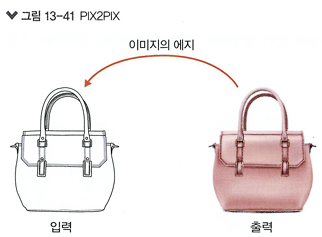

PIX2PIX의 훈련 역시 생성자와 판별자 네트워크를 이용한다.

#### 생성자 네트워크
PIX2PIX의 생성자 네트워크는 일반적인 생성자의 구조와 조금 다르다. 입력과 출력이 모두 이미지이기 때문에 전체적으로 크기가 줄어들었다가 다시 커지는 인코더-디코더의 구조이다. 크기가 줄어드는 인코더에서는 입력 데이터의 특징을 찾아내고, 크기가 다시 커지는 디코더에서는 이미지를 생성하는 역할을 한다. 출력층의 활성화 함수는 하이퍼볼릭 탄젠트로 -1~1 사이의 값을 갖는다. 그렇기 때문에 입력 또한 -1에서 1 사이의 값으로 변경해서 사용해야 한다.

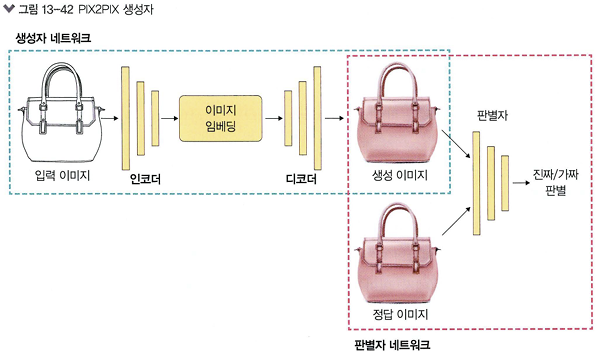

#### 판별자 네트워크
판별자 네트워크는 DCGAN과 마찬가지로 스트라이드가 2인 합성곱층으로 구성되어 있다. 하지만 뒤의 두 계층은 스트라이드가 1인 밸리드 합성곱을 이용하여 최종적으로 30X30 형태의 데이터를 출력한다. 일반적인 GAN 모델의 출력이 0~1 사이의 스칼라인 것과는 차이가 있는데, 출력에서 차이가 있는 이유는 판별자를 이미지의 각 부분별로 진행하기 위해서이다. 즉, 판별자는 이미지를 통째로 진짜인지 아닌지 판별하는 것이 아니라 이미지의 각 부분이 진짜인지 아닌지 판별한다. 이 과정에 따라 좀 더 디테일한 부분에 집중한 이미지를 판별할 수 있다. 또한, PIX2PIX의 훈련을 위한 손실 함수는 다음과 같다.

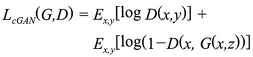

이때 생성자는 판별자를 속이는 것 말고도 생성한 이미지가 정답(입력 이미지)과 같아야 하는 과제가 있다. 이를 위해 PIX2PIX에서는 L1 손실 함수를 사용하며 수식은 다음과 같다.

image.png

따라서 L1 손실 함수가 추가된 최종 손실 함수는 다음과 같이 수정하여 사용된다.

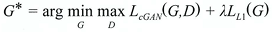


#### CycleGAN
PIX2PIX가 강력한 모델이기는 하지만 데이터 쌍이 필요하다는 단점이 있다. 예를 들어 다음 그림의 PIX2PIX 모델처럼 신발의 외곽선만 표현된 이미지에서 완전한 신발 이미지를 생성하고 싶다면, 신발의 외각선 이미지(x_i)와 신발 이미지(y_i)에 대한 데이터 쌍이 필요하다.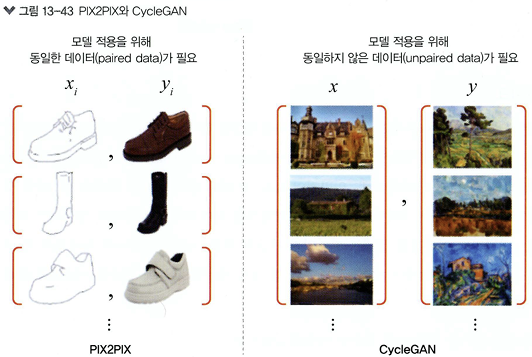


r그런데 이러한 데이터 쌍의 이미지를 구하는 것이 쉽지 않다. 예를 들어 흑백 이미지를 컬러 이미지로 변경하고 싶다면 동일한 그림에서 채색의 유무만 다른 이미지 두 개가 필요한데, 이러한 데이터를 얻기 어렵기 때문에 PIX2PIX 모델을 사용하기가 쉽지 않다, 따라서 쌍을 이루지 않는 이미지로 학습할 수 있는 방법이 필요한데, 이때 사용하는 것이 CycleGAN이다. CYcleGAN은 하나가 아닌 두 개(G,F)의 생성자를 갖는다. 생성자 G는 이미지 X를 이미지 Y로 변환하며, 생성자 F는 이미지 Y를 다시 이미지 X로 변환한다. 이때 D_x와 D_y는 각각 이미지 X와 Y를 위한 판별자이다. 따라서 생성자 G는 D_y에 대한 적대적 학습을 하며, 생성자 F는 D_x에 대한 적대적 학습을 한다.

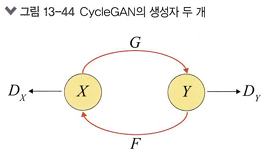

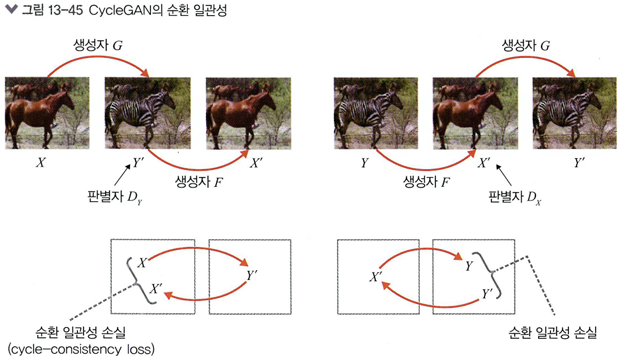

생성자 G는 조랑말 이미지 X를 얼룩말 이미지 Y'로 바꾸어주며, 생성자 F는 얼룩말 이미지 Y'를 조랑말 이미지 X'로 바꾸어 준다. 이때 G(X)는 조랑말 이미지 X가 생성자 G를 통해 변환된 이미지가 되며, 함수 적용 결과는 얼룩말 Y'가 된다. X가 얼마나 X'와 가까운지는 L1 손실 함수를 사용해서 계산한다. 또한, F(Y')는 얼룩말 이미지 Y'를 생성자 F를 통해 조랑말 X'로 변환한다. 즉, CycleGAN에서는 G(X)=Y'에 대한 생성자, Y' 값을 다시 X'로 복원하는 F(Y')=X'에 대한 생성자와 이 값을 판별하는 판별자(D_Y, D_X)가 추가되어 총 네 개의 네트워크를 사용한다. 이때 X->Y', Y'->X'로 연결되는 것을 순환 일관성이라고 한다. 다음 그림은 X->Y', Y'->X'로 연결되는 동작 과정을 보여준다. X->Y'를 정방향 일관성이라고 하며, Y'->X'를 역방향 일관성이라고 한다.

또한, 이때 사용되는 순환 일관성 손실 함수(L_cyc(G,F))의 수학적 정의는 다음과 같다.

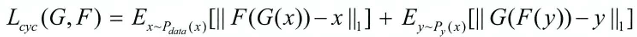

G(x)로 나온 y 값을 다시 F(y)를 통해 원본 이미지로 복원하고, 마찬가지로 F(y)로 나온 x값을 다시 G(x)를 통해 y로 복원하는 원리를 이용해서 전체 손실에 대한 함수를 정의하면 다음과 같다.

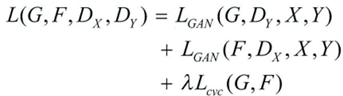

따라서 CycleGAN의 최종 목표는 다음 수식을 푸는 것이라고 할 수 있다.

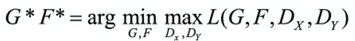

CycleGAN은 PIX2PIX처럼 생성자 하나, 판별자 하나를 사용하는 대신 생성자 둘, 판별자 둘을 사용한다. 따라서 CycleGAN은 이미지 X에서 이미지 Y로 변환하는 것뿐만 아니라 역방향으로도 변환이 진행된다. 그리고 생성자를 학습할 때는 손실 함수 L_cyc를 사용한다. 즉, CycleGAN은 PIX2PIX와 다르게(PIX2PIX 모델 학습은 L1 손실 함수에 의존적이므로 상대적으로 GAN 손실 함수의 역할이 작음) GAN 손실 함수가 핵심적인 역할을 하기 때문에 더 유연하게 이미지를 변환할 수 있다.